In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import io
from skimage.measure import label, regionprops

In [7]:
df = pd.read_csv(
    r"D:\hiPSC_Morphology_Project\data\processed\features_clustered.csv"
)

IMAGE_FOLDER = r"D:\hiPSC_Morphology_Project\data\raw_segmented_images"

print(df.shape)

(69714, 12)


In [8]:
example = df.sample(1, random_state=42).iloc[0]

print(example)

image_name             c4a521bd_3500000833_10X_20170414_11_27-Scene-0...
label                                                                  9
area                                                               522.0
perimeter                                                      85.740115
eccentricity                                                    0.437167
solidity                                                        0.959559
extent                                                          0.665816
major_axis_length                                              27.384306
minor_axis_length                                              24.628908
convex_area                                                        544.0
equivalent_diameter                                            25.780439
cluster                                                                0
Name: 55473, dtype: object


(1411, 1473)


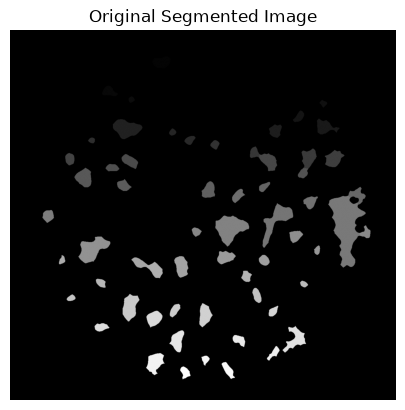

In [9]:
image_path = os.path.join(
    IMAGE_FOLDER,
    example["image_name"]
)

image = io.imread(image_path)

print(image.shape)

plt.imshow(image, cmap="gray")
plt.title("Original Segmented Image")
plt.axis("off")
plt.show()

In [10]:
labels = label(image)

print("Detected colonies:", labels.max())

Detected colonies: 61


In [11]:
target_label = int(example["label"])

mask = labels == target_label

print(mask.sum())

522


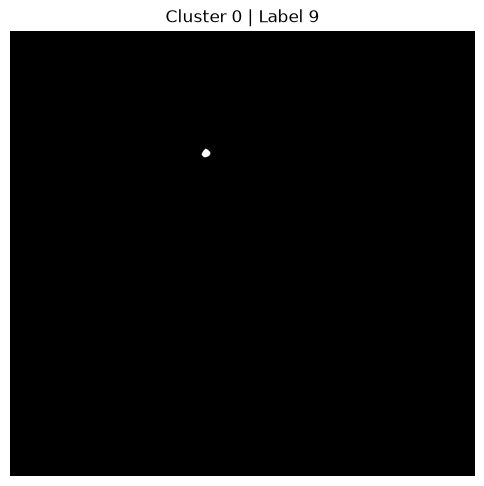

In [12]:
plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="gray")

plt.title(
    f"Cluster {example['cluster']} | Label {target_label}"
)

plt.axis("off")

plt.show()

In [13]:
import random
import os
import matplotlib.pyplot as plt
from skimage import io
from skimage.measure import label

IMAGE_FOLDER = r"D:\hiPSC_Morphology_Project\data\raw_segmented_images"

In [14]:
def show_random_colonies(cluster_id, n=6):

    samples = df[df["cluster"] == cluster_id].sample(n, random_state=42)

    fig, axes = plt.subplots(2, 3, figsize=(10,7))

    axes = axes.ravel()

    for ax, (_, row) in zip(axes, samples.iterrows()):

        image = io.imread(
            os.path.join(
                IMAGE_FOLDER,
                row["image_name"]
            )
        )

        labels = label(image)

        colony = labels == int(row["label"])

        ax.imshow(colony, cmap="gray")
        ax.set_title(
            f"A={row['area']:.0f}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

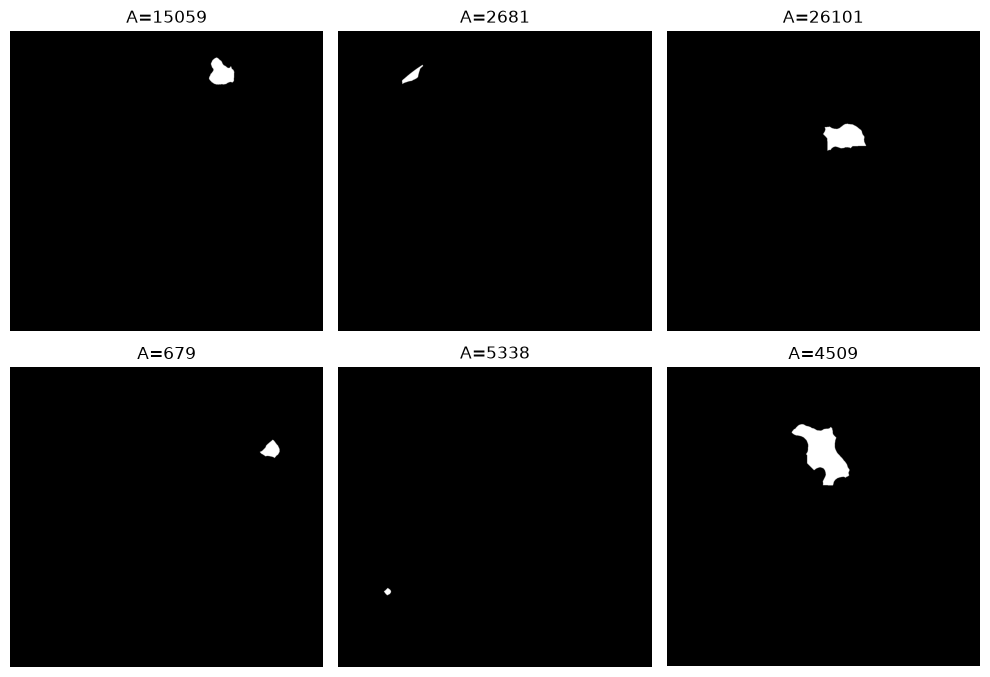

In [15]:
show_random_colonies(0)

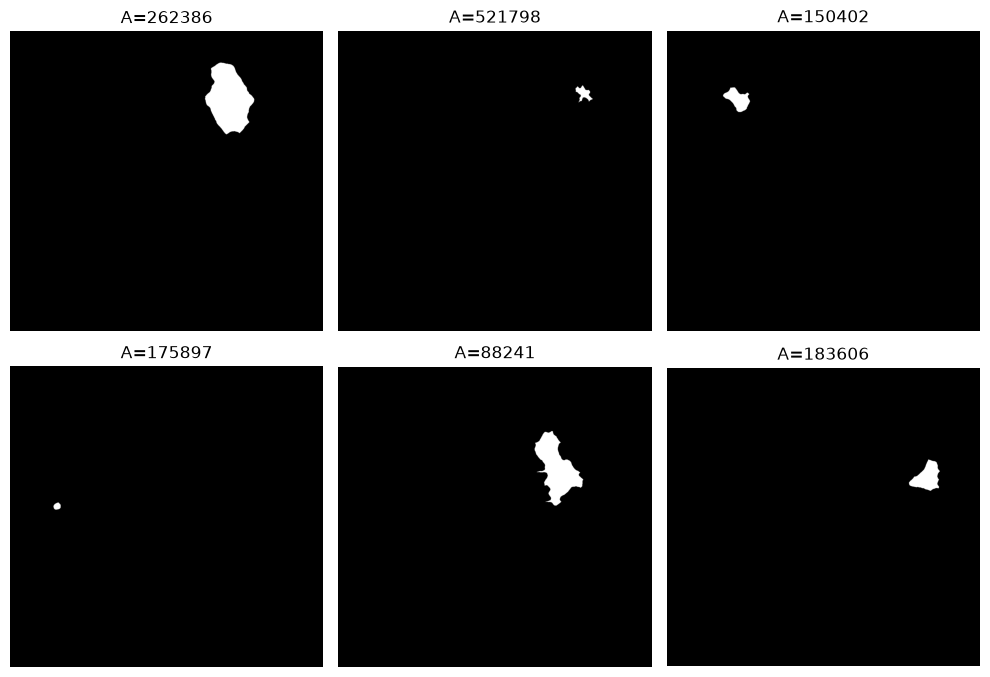

In [16]:
show_random_colonies(1)